In [1]:
import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap
from captum.attr import IntegratedGradients

warnings.filterwarnings('ignore')
gc.collect()

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


20

In [2]:
import os
if "CUDA_VISIBLE_DEVICES" in os.environ:
    del os.environ["CUDA_VISIBLE_DEVICES"]

In [3]:
# ── Config ───────────────────────────────────────────────────────────────────
DATA_PATH   = r"D:\ProyekDosen\RisetBearing\Dataset\bearing_1\processed_bearing1.parquet"
OUTPUT_DIR  = r"D:\ProyekDosen\RisetBearing\results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEGRADE_TRAIN_FRAC = 0.50  # fraction of degradation phase included in train
WINDOW_SIZE = 60
BATCH_SIZE  = 32
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.3
LR          = 1e-3
WEIGHT_DECAY= 1e-4
EPOCHS      = 50
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

META_COLS = ['segment','time_s','time_min','bhi','label_vcd','T_cp','T_f']
EMA_COLS  = ['rms_ema_x','rms_ema_y','rms_ema_z']
TARGET    = 'bhi'

plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 10, 'axes.grid': True,
    'grid.alpha': 0.3, 'lines.linewidth': 1.4, 'legend.fontsize': 9,
})

print(f"Device: {DEVICE}")

Device: cuda


In [4]:
# ── Data Loading & Temporal Split ────────────────────────────────────────────
def load_data():
    """TCP-aware temporal split: all healthy + first DEGRADE_TRAIN_FRAC of degradation → train."""
    df        = pd.read_parquet(DATA_PATH)
    feat_cols = [c for c in df.columns if c not in META_COLS + EMA_COLS]
    n         = len(df)

    tcp_segment = int(df['T_cp'].iloc[0])
    degrade_len = n - tcp_segment
    split_idx   = tcp_segment + int(degrade_len * DEGRADE_TRAIN_FRAC)

    X = df[feat_cols].values.astype(np.float32)
    y = df[TARGET].values.astype(np.float32)

    from sklearn.preprocessing import MinMaxScaler
    scaler        = MinMaxScaler()
    X[:split_idx] = scaler.fit_transform(X[:split_idx])
    X[split_idx:] = scaler.transform(X[split_idx:])

    X_train, y_train = X[:split_idx], y[:split_idx]
    X_test,  y_test  = X[split_idx:], y[split_idx:]

    t_min = df['time_min'].values

    print(f"TCP segment       : {tcp_segment}  ({tcp_segment/60:.2f} h)")
    print(f"Split segment     : {split_idx}  ({split_idx/60:.2f} h)")
    print(f"Train             : 0 → {split_idx}  ({split_idx} segments, BHI {y_train.min():.2f}–{y_train.max():.2f})")
    print(f"Test              : {split_idx} → {n}  ({n-split_idx} segments, BHI {y_test.min():.2f}–{y_test.max():.2f})")
    print(f"Feature count     : {len(feat_cols)}")
    return X_train, y_train, X_test, y_test, feat_cols, t_min, split_idx

X_train, y_train, X_test, y_test, FEATURE_COLS, T_MIN, SPLIT_IDX = load_data()


TCP segment       : 2381  (39.68 h)
Split segment     : 4430  (73.83 h)
Train             : 0 → 4430  (4430 segments, BHI 0.50–1.00)
Test              : 4430 → 6480  (2050 segments, BHI 0.00–0.50)
Feature count     : 54


In [5]:
# ── Dataset & DataLoader ─────────────────────────────────────────────────────
class SequenceDataset(Dataset):
    """Sliding-window sequence dataset for LSTM input."""
    def __init__(self, X, y, window):
        xs, ys = [], []
        for i in range(len(X) - window):
            xs.append(X[i:i+window])
            ys.append(y[i+window-1])
        self.X = torch.tensor(np.array(xs), dtype=torch.float32)
        self.y = torch.tensor(np.array(ys), dtype=torch.float32).unsqueeze(1)

    def __len__(self):              return len(self.X)
    def __getitem__(self, idx):     return self.X[idx], self.y[idx]

train_ds = SequenceDataset(X_train, y_train, WINDOW_SIZE)
test_ds  = SequenceDataset(X_test,  y_test,  WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train sequences: {len(train_ds)}  |  Test sequences: {len(test_ds)}")


Train sequences: 4370  |  Test sequences: 1990


In [6]:
# ── Model Architecture ───────────────────────────────────────────────────────
class RULLSTM(nn.Module):
    """Stacked LSTM with FC head for BHI regression."""
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, HIDDEN_SIZE, NUM_LAYERS,
                            batch_first=True, dropout=DROPOUT)
        self.fc1  = nn.Linear(HIDDEN_SIZE, 64)
        self.fc2  = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.lstm(x)
        out     = self.relu(self.fc1(out[:, -1, :]))
        return torch.sigmoid(self.fc2(out))

model = RULLSTM(input_size=len(FEATURE_COLS)).to(DEVICE)
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")


Model params: 234,625


In [7]:
# ── Training ─────────────────────────────────────────────────────────────────
def train(model, loader):
    """MSE training with degradation-phase weighting and LR scheduling."""
    criterion = nn.MSELoss(reduction='none')
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)
    history   = []

    for epoch in range(EPOCHS):
        model.train()
        losses = []
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred    = model(Xb)
            weights = torch.where(yb < 0.98,
                                  torch.tensor(10.0, device=DEVICE),
                                  torch.tensor(1.0,  device=DEVICE))
            loss = (criterion(pred, yb) * weights).mean()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(loss.item())

        avg = np.mean(losses)
        history.append(avg)
        scheduler.step(avg)
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{EPOCHS}  loss={avg:.6f}  lr={optimizer.param_groups[0]['lr']:.2e}")

    return history

print("\nTraining...")
loss_history = train(model, train_loader)



Training...
Epoch   1/50  loss=0.027231  lr=1.00e-03
Epoch  10/50  loss=0.044497  lr=5.00e-04
Epoch  20/50  loss=0.142566  lr=1.25e-04
Epoch  30/50  loss=0.150030  lr=6.25e-05
Epoch  40/50  loss=0.148805  lr=1.56e-05
Epoch  50/50  loss=0.148558  lr=3.91e-06


In [8]:
# ── Evaluation ────────────────────────────────────────────────────────────────
def evaluate(model, loader):
    """Run inference on a DataLoader; returns (y_true, y_pred) arrays."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            preds.extend(model(Xb.to(DEVICE)).cpu().numpy().flatten())
            trues.extend(yb.numpy().flatten())
    return np.array(trues), np.array(preds)

def metrics(y_true, y_pred):
    """RMSE, MAE, R² + PRONOSTIA asymmetric scoring function."""
    err   = y_pred - y_true
    score = np.sum(np.where(err < 0, np.exp(-err/13)-1, np.exp(err/10)-1))
    return {
        'RMSE' : np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE'  : mean_absolute_error(y_true, y_pred),
        'R2'   : r2_score(y_true, y_pred),
        'Score': score,
    }

y_true, y_pred = evaluate(model, test_loader)
m = metrics(y_true, y_pred)
print("\nTest Set Metrics:")
for k, v in m.items():
    print(f"  {k:6s}: {v:.4f}")

# save predictions
pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}).to_excel(
    os.path.join(OUTPUT_DIR, 'predictions.xlsx'), index=False)



Test Set Metrics:
  RMSE  : 0.6131
  MAE   : 0.5969
  R2    : -18.1304
  Score : 122.6055


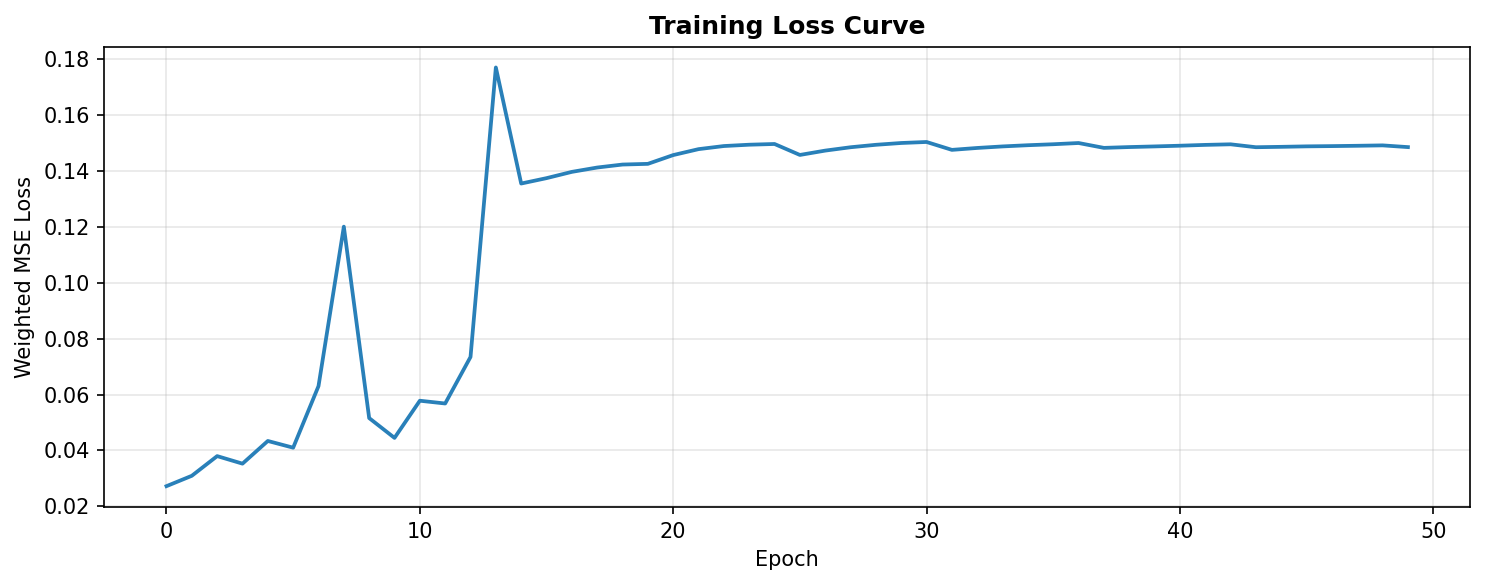

In [9]:
# ── Visualizations ────────────────────────────────────────────────────────────
# Plot 1: Training loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(loss_history, color='#2980B9', lw=1.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted MSE Loss')
ax.set_title('Training Loss Curve', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot1_training_loss.png'), dpi=200, bbox_inches='tight')
plt.show()

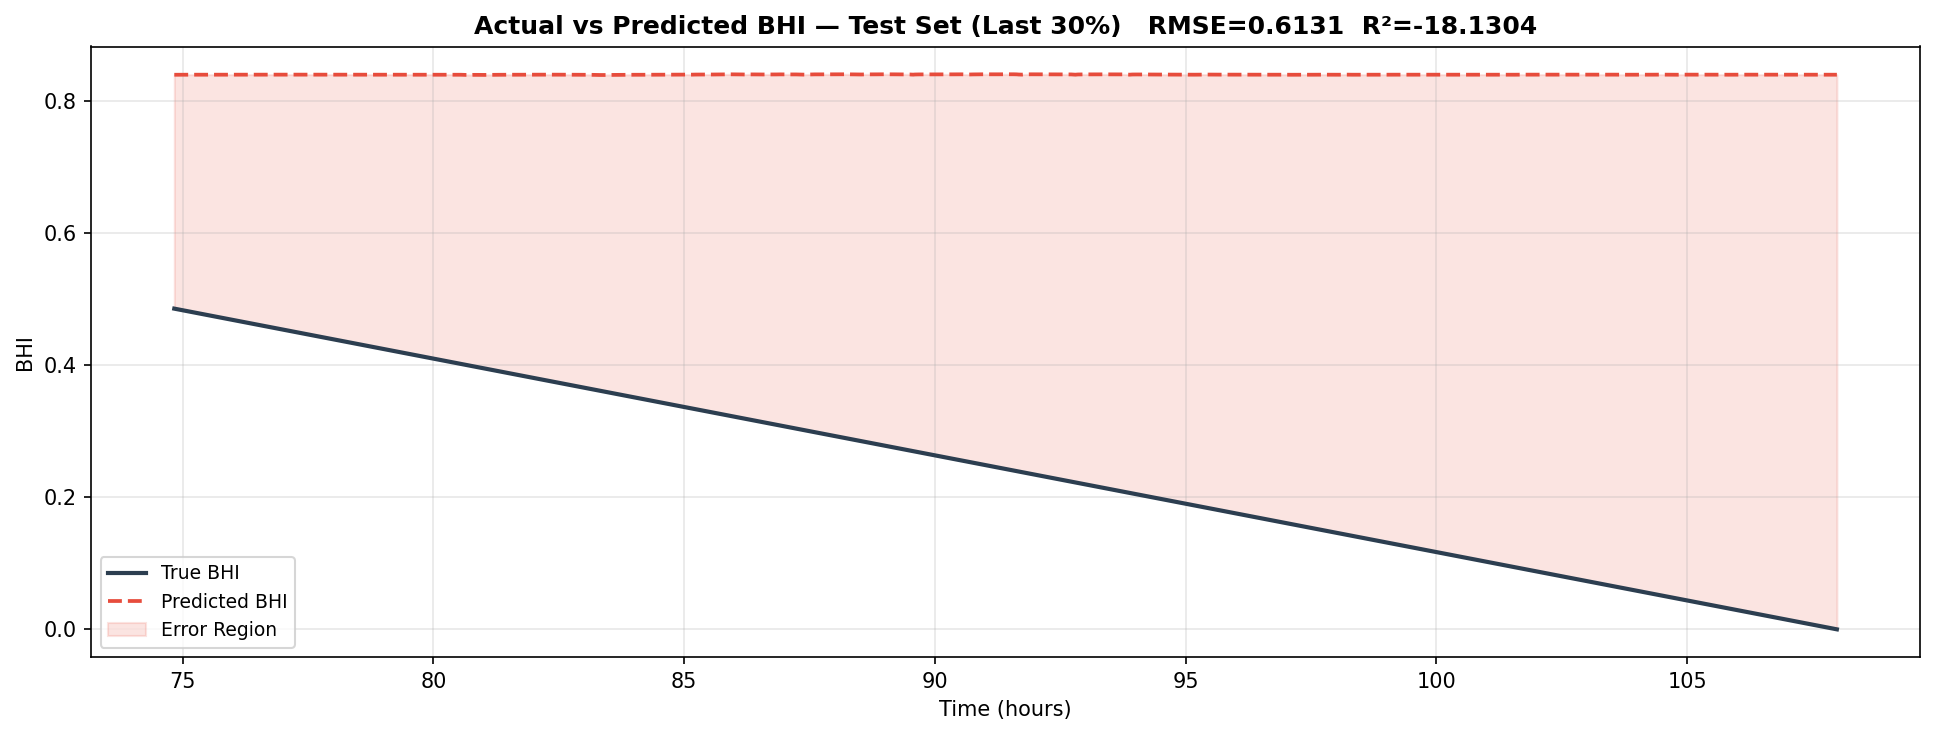

In [10]:
# Plot 2: Actual vs Predicted BHI on Test Set
# Align time axis: test set starts at SPLIT_IDX + WINDOW_SIZE
test_time = T_MIN[SPLIT_IDX + WINDOW_SIZE: SPLIT_IDX + WINDOW_SIZE + len(y_true)] / 60

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_time, y_true, color='#2C3E50',   lw=2.0, label='True BHI')
ax.plot(test_time, y_pred, color='#E74C3C',   lw=1.8, ls='--', label='Predicted BHI')
ax.fill_between(test_time, y_true, y_pred, alpha=0.15, color='#E74C3C', label='Error Region')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('BHI')
ax.set_title(f'Actual vs Predicted BHI — Test Set (Last 30%)   '
             f'RMSE={m["RMSE"]:.4f}  R²={m["R2"]:.4f}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot2_bhi_prediction.png'), dpi=200, bbox_inches='tight')
plt.show()

In [11]:
# ── XAI — Integrated Gradients (Captum) ─────────────────────────────────────
print("\nRunning XAI analysis...")
model.eval()

bg_tensor   = test_ds.X[:200].to(DEVICE)
xai_tensor  = test_ds.X[200:250].to(DEVICE)

ig          = IntegratedGradients(model)
attrs, _    = ig.attribute(xai_tensor, baselines=torch.zeros_like(xai_tensor),
                            target=None, return_convergence_delta=True)
# Aggregate over time window → mean abs attribution per feature
attr_np     = attrs.cpu().detach().numpy()           # (N, W, F)
attr_mean   = np.abs(attr_np).mean(axis=(0, 1))      # (F,)

ig_series = pd.Series(attr_mean, index=FEATURE_COLS).sort_values(ascending=False)
top_ig    = ig_series.head(20).sort_values()

# ── XAI — SHAP GradientExplainer ────────────────────────────────────────────
explainer   = shap.GradientExplainer(model, bg_tensor)
shap_vals   = explainer.shap_values(xai_tensor)
sv          = shap_vals[0] if isinstance(shap_vals, list) else shap_vals  # (N, W, F)
sv_mean     = np.abs(sv).mean(axis=(0, 1))    # (F,)

shap_series = pd.Series(sv_mean, index=FEATURE_COLS).sort_values(ascending=False)
top_shap    = shap_series.head(20).sort_values()



Running XAI analysis...


RuntimeError: cudnn RNN backward can only be called in training mode

In [ ]:
# Plot 3: Integrated Gradients top-20
fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(top_ig.index, top_ig.values, color='#16A085', edgecolor='none', height=0.7)
ax.set_xlabel('Mean |Attribution|')
ax.set_title('Top 20 Features — Integrated Gradients', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot3_integrated_gradients.png'), dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Plot 4: SHAP feature importance bar
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_shap.index, top_shap.values, color='#8E44AD', edgecolor='none', height=0.7)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top 20 Features — SHAP GradientExplainer', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot4_shap_importance.png'), dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Plot 5: Side-by-side comparison IG vs SHAP (top 15 overlap)
top_k       = 15
common_feats= list(dict.fromkeys(list(ig_series.head(top_k).index) + list(shap_series.head(top_k).index)))
ig_norm     = ig_series[common_feats] / (ig_series[common_feats].max() + 1e-12)
shap_norm   = shap_series[common_feats] / (shap_series[common_feats].max() + 1e-12)
compare_df  = pd.DataFrame({'IG (norm)': ig_norm, 'SHAP (norm)': shap_norm}).sort_values('IG (norm)')

fig, ax = plt.subplots(figsize=(9, 7))
y_pos = np.arange(len(compare_df))
ax.barh(y_pos - 0.2, compare_df['IG (norm)'],   0.38, color='#16A085', label='Integrated Gradients')
ax.barh(y_pos + 0.2, compare_df['SHAP (norm)'], 0.38, color='#8E44AD', label='SHAP')
ax.set_yticks(y_pos)
ax.set_yticklabels(compare_df.index, fontsize=8)
ax.set_xlabel('Normalised Attribution')
ax.set_title('XAI Comparison — IG vs SHAP (Top Features)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot5_xai_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MODELING SUMMARY")
print("=" * 55)
print(f"Split ratio         : {int(TRAIN_RATIO*100)}/{int((1-TRAIN_RATIO)*100)} (temporal)")
print(f"Window size         : {WINDOW_SIZE}  |  Batch: {BATCH_SIZE}")
print(f"Architecture        : LSTM {NUM_LAYERS}L × {HIDDEN_SIZE}h → FC64 → sigmoid")
print(f"Epochs              : {EPOCHS}")
print(f"Test RMSE           : {m['RMSE']:.4f}")
print(f"Test MAE            : {m['MAE']:.4f}")
print(f"Test R²             : {m['R2']:.4f}")
print(f"PRONOSTIA Score     : {m['Score']:.2f}")
print(f"Top IG feature      : {ig_series.index[0]}")
print(f"Top SHAP feature    : {shap_series.index[0]}")
print(f"Results saved to    : {OUTPUT_DIR}")
print("=" * 55)
